<a href="https://colab.research.google.com/github/sidle34/allofthestuff/blob/main/SignLanguageInterpreter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GRADTDA5622 - Big Data Computing Foundations 2
## Final Project: Sign Language Translator
Replace the example information below with your real information:
- Semester: Spring 2025
- Instructor: Brad Coy
- Section: 3716
- Student Name(s): Erin Sidle, Monica Smith, Brooklyn Spears
- Student Email(s): smith.16452@osu.edu, sidle.34@osu.edu, spears.180@osu.edu
- Student ID(s): ERIN: , MONICA: , BROOKLYN: 500283070
***

***
# Section: Overview
- Insert a short description of the scope of this exercise, any supporting information, etc.
- **(I will fill this in for each assignment - Tom Bihari)**
***

### Assignment Overview
In this assignment, you will build a sign language translator.

**The Objectives of This Assignment are:**
1. To perform a classification task on image data, using the K-Nearest-Neighbors algorithm from the SciKit-Learn library https://scikit-learn.org/stable/).
2. To understand domain-independent evaluation measures.
3. To understand the impact meta-parameters have in algorithm performance
4. To develop a tool that uses the classification model that was developed.
5. To get practice discussing / explaining your results, findings, and insights.

### Problem Statement
Assume that you are the Director of Data Science for American Signing, Inc. (ASI), a company that provides innovative sign-language solutions.  ASI has new technology that can capture American Sign Language images in real time.  ASI would like your team to design a new product that can translate ASL images to text.

### Things To Do
The follow the instructions for each step in the sections below.

### Notes

- This dataset has exactly the same format as the "standard" MNIST dataset that is widely used.  See the link below for the documentation of the dataset.  You also can search for MNIST in the web.
  - This dataset was pulled on 4/13/23 from: https://www.kaggle.com/code/madz2000/cnn-using-keras-100-accuracy
  - See also: https://en.wikipedia.org/wiki/MNIST_database
  - These are 28x28 gray-scale pixel images, with 256-color (or gray-scale) values.
- You will use the KNN classifier that is provided in the SciKit Learn library (similar to the Case Studies you have done).  You do not need to write your own.
- You will be adjusting the number of training records for the exercise (so it runs reasonably fast), so you do not need to run the algorithm on "all" training records.
- Some code is provided (partially filled in) to assist in the development of the final product - this is a starting point.  You may adjust it as you choose.
- By the way, this exercise is identical to one where, for example, the images are medical scans, etc., and you are trying to classify cells as diseased or healthy.  (There are lots of MNIST examples on the web.)

It is essential that you **communicate** your goals, thought process, actions, results, and conclusions to the **audience** that will consume this work.  It is **not enough** to show just the code.  It is not appropriate to show long sections of **unexplained printout**, etc.  Be kind to your readers and provide value to them!

**ALWAYS follow this pattern** when doing **each portion** of the work.  This allows us to give feedback and assign scores, and to give partial credit.  Make it easy for the reader to understand your work.
- Say (briefly) **what** you are trying to do, and **why**.
- Do it (code).
- Show or describe the **result** clearly (and briefly as needed), and explain the significant **conclusions or insights** derived from the results.

**HAVE FUN!**

***
# Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

In [ ]:
# Convert label numbers 0-25 to characters A-Z
def label_to_letter(label_num):
    return chr(ord('A') + label_num)

# Convert characters A-Z to label numbers 0-25
def letter_to_label(letter):
    return ord(letter) - ord('A')

# Take a numpy array of y labels (true or predicted) and build a string with the decoded letters
def y_labels_to_string(y_array):
    st = ""
    for num in np.nditer(y_array):
        st += label_to_letter(num)
    return st

This is a needed translation step that will eventually create an output useful for nontechnical people.
This translates numbers to letters or words.

***
# Read the Data

In [ ]:
# Establish the file path (ONLY edit the user name 'bcoy48', if obtaining from your own forked repo)
fpath = "https://bcoy48.github.io/osu-gradtda-5622-sp25/course_materials/final"

# Read the training data
# train_pdf = pd.read_csv('../shared/sign_mnist_train.csv')
train_pdf = pd.read_csv(f'{fpath}/sign_mnist_train.csv')

In [ ]:
# Read the test data
# test_pdf = pd.read_csv('../shared/sign_mnist_test.csv')
test_pdf = pd.read_csv(f'{fpath}/sign_mnist_test.csv')
test_pdf.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,...,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000
mean,11.247351,147.532627,150.445761,153.324317,155.663413,158.169688,160.790853,162.282766,163.649191,165.589515,...,138.546570,145.539598,150.744980,155.638873,158.893196,159.648494,158.162019,157.672755,156.664250,154.776771
std,7.446712,43.593144,41.867838,40.442728,39.354776,37.749637,36.090916,36.212636,35.885378,33.721876,...,64.501665,65.132370,65.760539,65.565147,65.200300,65.499368,66.493576,66.009690,67.202939,68.285148
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,122.000000,126.000000,130.000000,134.000000,137.000000,141.000000,144.000000,145.000000,147.000000,...,90.000000,95.000000,99.000000,105.000000,113.000000,113.750000,113.000000,115.000000,111.000000,106.750000
50%,11.000000,154.000000,157.000000,159.000000,161.000000,163.000000,165.000000,166.000000,168.000000,169.000000,...,137.000000,155.000000,168.000000,177.000000,181.000000,182.000000,181.000000,180.000000,180.000000,179.000000
75%,18.000000,178.000000,179.000000,181.000000,182.000000,184.000000,185.000000,186.000000,187.000000,187.000000,...,195.000000,200.000000,204.250000,207.000000,207.000000,208.000000,207.000000,205.000000,206.000000,204.000000
max,24.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


This step loads the trainng data from GitHub.
Next, it stores this file into a dataframe called train_pdf, which will be used to train our model.

***
# Pre-process the Data for Use

In [ ]:
# Normally, you might do EDA here to analyze and handle missing or bad values, transform or eliminate columns, scale values, etc.
# We don't have to do this with this dataset.

In [ ]:
# Split the training and test datasets into X and y parts.
# y contains the labels (first column)
# X contains the attributes (remaining columns of the dataset)

train_row_count = train_pdf.shape[0]  # Gives number of rows
train_col_count = train_pdf.shape[1]  # Gives number of columns
test_row_count  =  test_pdf.shape[0]  # Gives number of rows
test_col_count  =  test_pdf.shape[1]  # Gives number of columns
print(train_row_count,train_col_count,test_row_count,test_col_count)

num_train = 6000  # Trim the number of training rows to use (you will adjust this later when optimizing)
num_test  = 1000  # Trim the number of test rows to use (don't change this)

y_train = train_pdf.iloc[:num_train, 0]
X_train = train_pdf.iloc[:num_train, 1:-1]

y_test = test_pdf.iloc[:num_test, 0]
X_test = test_pdf.iloc[:num_test, 1:-1]

27455 785 7172 785


This prepares a selection of data from our dataset for our machine learning model. We will be using K-Nearest Neighbors(KNN).
First, we store the numbers of rows and colums in the test and training datasets. This is useful in debugging if needed.
Then we limit the number of samples (train and test), so the KNN model can run more quickly. Once everything is finetuned, we can increase this number for accuracy.


***
# Run the K-Nearest-Neighbors Algorithm

In [ ]:
# Set a value for K (you will adjust this later when optimizing)
K = 5

In [ ]:
# Initialize the SciKit-Learn classifer and fit the data (train the classifier)
classifier = KNeighborsClassifier(n_neighbors=K, metric='euclidean', weights='distance')
classifier.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

This first step sets the number of nearest neighbors the model will use to classify new examples.
It will look for the 5 nearest training points to make each prediction.
The next steps help find which values are closes to our target value(5).
The weighted distance improves accuracy by giving more "weight" to the closer neighbors. This will improve accuracy.

In [ ]:
# Predict the test data
y_pred = classifier.predict(X_test)

In [ ]:
# Compute confusion matrix, classification report, and accuracy score
conf_matrix = confusion_matrix(y_test,y_pred)
classif_report = classification_report(y_test,y_pred)

print('Confusion Matrix (Rows=Actual, Cols=Predicted)')
print(conf_matrix)
print('\nClassification Report')
print(classif_report)
print('\nAccuracy:', accuracy_score(y_test,y_pred))

Confusion Matrix (Rows=Actual, Cols=Predicted)
[[41  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 56  0  3  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  1  1  0  0  0]
 [ 0  0 39  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 31  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  2  0  0  0  0]
 [ 1  0  0  0 59  0  0  0  0  0  0  3  0  0  0  0  0  8  0  0  0  0  0  0]
 [ 0  2  1  0  0 30  0  0  0  0  3  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  1 47  2  0  0  0  1  0  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0  7 52  0  0  0  0  0  0  0  0  0  0  2  0  1  0  0  0]
 [ 2  4  0  0  2  0  0  0 29  0  0  1  1  0  0  0  0  4  0  0  0  0  0  0]
 [ 0  0  0  2  0  0  0  0  1 23  0  0  0  0  0  0  4  0  0  6  3  6  0  0]
 [ 0  0  0  0  0  1  0  3  0  0 17  0  0  0  0  0  0  0  2  0  0  0  0  0]
 [10  0  0  0 12  0  0  0  0  0  0 24 11  0  0  0  0  6  0  0  0  0  0  0]
 [ 2  0  1  0  6  0  0  0  0  0  0  3 17  0  0  2  0 

## Evaluate the classification errors
- Describe the errors qualitatively.  What do you notice?

The output seems to have issues determining letters that have similar finger placement but different views. We see
this with letters K and D where one has palm facing out and the other forward. It also has difficulty differentiating
how many fingers. ASL letter H has two and ASL letter G has one.

In [ ]:
# Show an image taken from a row in an image dataframe (e.g., test_df).
import matplotlib.pyplot as plt
def show_image(caption,pixels):
    plt.figure(figsize=(1, 1))
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.title(caption)
    image = np.asarray(pixels).reshape((28,28))  #print(image.shape)
#    https://matplotlib.org/stable/tutorials/colors/colormaps.html
#    plt.imshow(image, cmap='gray', vmin = 0, vmax = 255, interpolation='none') #with grayscale colormap
    plt.imshow(image) #with default colormap (viridis)
    plt.show()

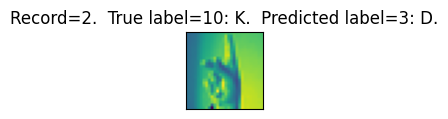

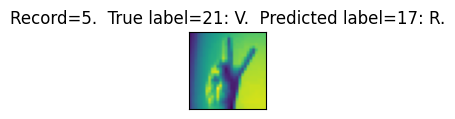

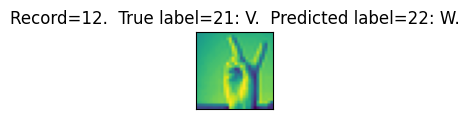

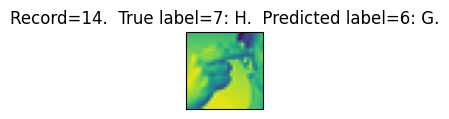

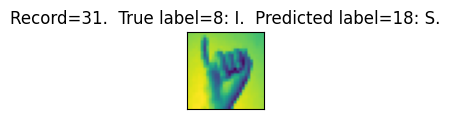

Not all shown.


In [ ]:
# Show test records that are mis-classified.
max_to_show = 5  # Limit the display
shown = 0
for i in range(min(len(y_test), len(y_pred))):
    if(y_pred[i] != y_test[i]):
        my_pred_label = y_pred[i]
        my_true_label  = y_test[i]
        my_pixels = test_pdf.iloc[i,1:]
        caption = "Record=" + str(i) + \
            ".  True label=" +      str(my_true_label) + ": " + label_to_letter(my_true_label) + \
            ".  Predicted label=" + str(my_pred_label) + ": " + label_to_letter(my_pred_label) + "."
        show_image(caption,my_pixels)
        shown += 1
        if shown >= max_to_show:
            print("Not all shown.")
            break

***
# Optimize
- Now we want to see how the behavior of the algorithm changes based on the meta-parameters.  The inputs are:
  - Different values for **K**
  - Different values for **num_train** (number of training records)
- The metrics are:
  - Accuracy
  - Running Time (This is secondary, but helps ensure the processing doesn't take too long.)

## Take the code you created above and make it into a single function with this shape:
- my_accuracy, my_running_time = **run_knn**( K, num_train )

In [ ]:
#Fill in the parts of the function
def run_knn(K,num_train):
    start_time = time.time() # Record the start time
    train_row_count = train_pdf.shape[0]  # Gives number of rows
    train_col_count = train_pdf.shape[1]  # Gives number of columns
    test_row_count  =  test_pdf.shape[0]  # Gives number of rows
    test_col_count  =  test_pdf.shape[1]  # Gives number of columns
    num_train = num_train  # Trim the number of training rows to use
    num_test  = 1000  # Trim the number of test rows to use (don't change this)

    y_train = train_pdf.iloc[:num_train, 0]
    X_train = train_pdf.iloc[:num_train, 1:-1]

    y_test = test_pdf.iloc[:num_test, 0]
    X_test = test_pdf.iloc[:num_test, 1:-1]
    classifier = KNeighborsClassifier(n_neighbors=K, metric='euclidean', weights='distance')
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    acc=accuracy_score(y_test,y_pred) #predicting accuracy
    end_time = time.time() # Record the end time
    run_time = end_time - start_time # Run Time
    return acc, run_time

## Try various values for **K** and graph the results
- Try K = 1-20 or so.
- Use 6000 for num_train
- Choose a "best" value for K

In [ ]:
# Fill in
Ks = range(1, 21) # Setting this to use values 1-20
accus = [] # Creating an empty list to store accuracy results
run_times = [] # Creating an empty list to store run time results
for K in Ks: # Creating a loop for the values
    acc, run_time = run_knn(K, 6000) # Adding the results for the function using k=1-20 and num_train=6000
    accus.append(acc) # Append the accuracy result
    run_times.append(run_time) # Append the run time result
print("Accuracies:", accus)
print("Run Times:", run_times)


Accuracies: [0.757, 0.757, 0.745, 0.742, 0.729, 0.731, 0.716, 0.715, 0.71, 0.711, 0.702, 0.691, 0.687, 0.679, 0.681, 0.669, 0.67, 0.666, 0.657, 0.657]
Run Times: [0.4913492202758789, 0.5239691734313965, 0.4675872325897217, 0.4750955104827881, 0.488353967666626, 0.47722959518432617, 0.4952046871185303, 0.4768345355987549, 0.5450916290283203, 0.5440638065338135, 0.5044121742248535, 0.48129725456237793, 0.4987039566040039, 0.48109960556030273, 0.5044012069702148, 0.4887075424194336, 0.5234401226043701, 0.5449883937835693, 0.574429988861084, 0.8571827411651611]


Text(0, 0.5, 'Accuracy')

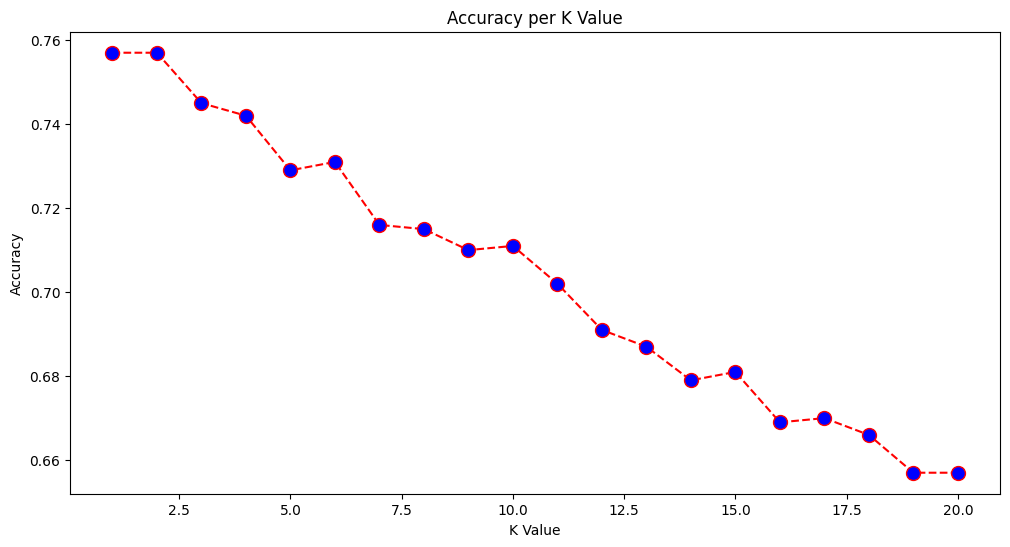

In [ ]:
# Graph Accuracy:
plt.figure(figsize=(12, 6))
plt.plot(Ks, accus, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('Accuracy per K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

As we increase our K value, our accuracy decreases. We see the highest level of accuracy with K at 1 or 2.
That is not the best K as it will overfit the data. To select our best K-value we will use the elbow method, which
would lead to us selecting K=5

## Try various values for **num_train** and graph the results
- Try num_train for several values in multiples of 1000.
- Use a value for K that worked well above.
- Choose a "best" value for num_train.

In [ ]:
#Fill in
K=5
num_train_values = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000] #setting this to use values 1000-10,000

accus_train = [] # Creating an empty list to store accuracy results
run_times_train = [] # Creating an empty list to store run time results
for num_train in num_train_values: # Creating a loop for the values
  my_accuracy, my_running_time = run_knn(K, num_train) # Adding the results for the function using k=1-20 and num_train=6000
  accus_train.append(my_accuracy) # Append the accuracy result
  run_times_train.append(my_running_time) # Append the run time result
print("Accuracies:", accus_train)
print("Run Times:", run_times_train)



Accuracies: [0.519, 0.605, 0.651, 0.692, 0.715, 0.729, 0.743, 0.746, 0.75, 0.757]
Run Times: [0.10949325561523438, 0.23467016220092773, 0.3942089080810547, 0.6724100112915039, 0.5201458930969238, 0.5143375396728516, 0.5419063568115234, 0.7544963359832764, 1.1722450256347656, 1.1867196559906006]


Text(0, 0.5, 'Accuracy')

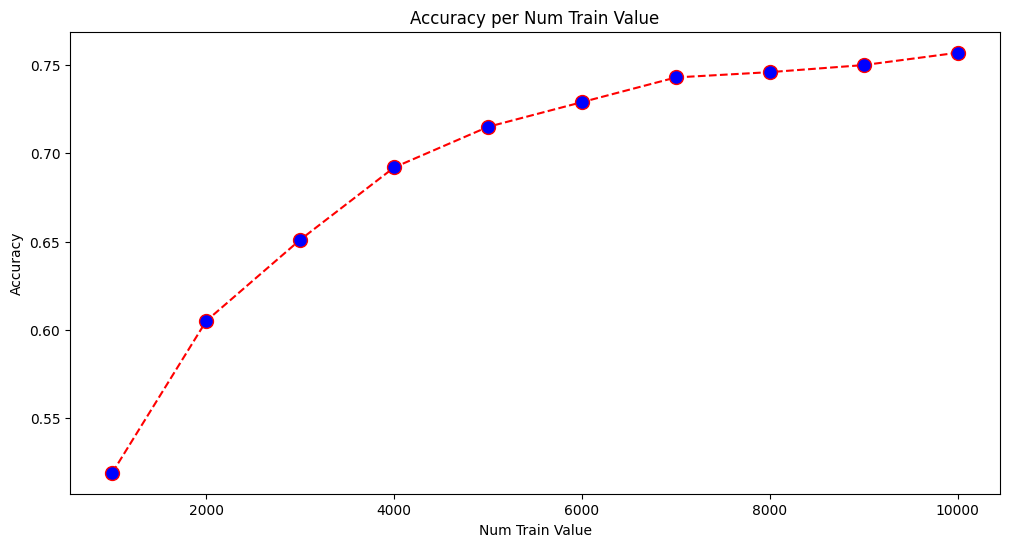

In [ ]:
# Graph Accuracy
# Fill in
plt.figure(figsize=(12, 6))
plt.plot(num_train_values, accus_train, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('Accuracy per Num Train Value')
plt.xlabel('Num Train Value')
plt.ylabel('Accuracy')

As shown by the figure and accuracy results, we see accuracy increase as we increase our num train value. This is
because we are training more and more data. We also see that the run time increases as well since there is more
data to train. The same issue as before, that selecting too much or too little will overfit the model.
Looking at the graph we see that the accuracy starts to plateau around 7000, so it may be best to select that value.

***
# Create a Sign Language to Text Translator
- Now we want to build a translator that takes as input a CSV file of sign language images and prints out the corresponding text.
- The translator will work as follows:
  - Based on the experiments you ran above, choose a "best" K value and "num_train" value.
  - Create a new classifier using these parameters and train it on the training data (as you did above).
  - Create a function "translate_signs_to_text" that processes a CSV file of images.

## Based on the code you created above and make it into a single function with this shape:


In [ ]:
# Initialize a SciKit-Learn classifer and fit the data (train the classifier)
#   with the "best" configuration parameters you "chose" above.

chosen_K = 5        # Fill this in
chosen_num_train = 7000  # Fill this in

y_train = train_pdf.iloc[:chosen_num_train, 0]
X_train = train_pdf.iloc[:chosen_num_train, 1:-1]

classifier = KNeighborsClassifier(n_neighbors=chosen_K, metric='euclidean', weights='distance')
classifier.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

In [ ]:
# Fill in this function
def translate_signs_to_text(input_sign_csv_filename):
    # Read the CSV file into a DataFrame
    input_pdf = pd.read_csv(input_sign_csv_filename)

    # Split into true labels and pixel features
    y_true = input_pdf.iloc[:, 0]
    X = input_pdf.iloc[:, 1:-1]


    # Predict labels
    y_pred = classifier.predict(X)

    # Convert arrays to readable strings

    true_text = [str(label) for label in y_true]
    pred_text = [str(label) for label in y_pred]


    # Calculate accuracy
    acc = accuracy_score(y_true, y_pred)

    return true_text, pred_text, acc

In [ ]:
# Translate Message1
# true_text, pred_text, acc = translate_signs_to_text('../shared/sign_mnist_message1.csv')
# true_text, pred_text, acc = translate_signs_to_text('/content/sign_mnist_message1.csv')
true_text, pred_text, acc = translate_signs_to_text(f'{fpath}/sign_mnist_message1.csv')
print("PRED:",pred_text)
# Guess the actual message. Guess: Go Buckeyes. Results Shown Below: GO BUCDEREN

PRED: ['6', '14', '1', '20', '2', '3', '4', '17', '4', '13']


In [ ]:
# Now print the true message and the accuracy.  Were you right?
  #Our guess was right even though some of the predicted letters were wrong
print("TRUE:",true_text)
print("ACC: ",acc)

TRUE: ['6', '14', '1', '20', '2', '10', '4', '24', '4', '18']
ACC:  0.7


In [ ]:
# Translate Message2
# true_text, pred_text, acc = translate_signs_to_text('../shared/sign_mnist_message2.csv')
# true_text, pred_text, acc = translate_signs_to_text('/content/sign_mnist_message2.csv')
true_text, pred_text, acc = translate_signs_to_text(f'{fpath}/sign_mnist_message2.csv')
print("PRED:",pred_text)
# Guess the actual message. Guess: Happy Summer. Results Shown Below: HAPPY NUMMEU

PRED: ['7', '0', '15', '15', '17', '13', '20', '12', '12', '4', '20']


In [ ]:
# Now print the true message and the accuracy.  Were you right?
  #Our guess was right even though some of the predicted letters were wrong
print("TRUE:",true_text)
print("ACC: ",acc)

TRUE: ['7', '0', '15', '15', '24', '18', '20', '12', '12', '4', '17']
ACC:  0.7272727272727273


In [ ]:
# Translate Message3
#true_text, pred_text, acc = translate_signs_to_text('../shared/sign_mnist_message3.csv')
#true_text, pred_text, acc = translate_signs_to_text('/content/sign_mnist_message3.csv')
true_text, pred_text, acc = translate_signs_to_text(f'{fpath}/sign_mnist_message3.csv')
print("PRED:",pred_text)
# Guess the actual message. #Guess: Call me Ishmael. Some years ago—never mind how long precisely—having little or no money in my purse,
  #and nothing particular to interest me on shore, I thought I would sail about a little and see the watery part of the world.
  #Results Shown Below: call me in hameloner eau na goser eureumisdhowlosgpuecinelrhari sg litt leousomoser is mrpuunea sdsothisgpatsiculats
  # oist euentmeosnhoteithotgh tiwotldmailabot salitt eeasdmeethewat eurpats of the wotld

PRED: ['2', '0', '11', '11', '12', '4', '8', '13', '7', '12', '0', '4', '11', '13', '14', '12', '4', '17', '4', '0', '20', '13', '0', '6', '14', '18', '4', '17', '4', '20', '12', '8', '18', '3', '7', '14', '22', '11', '14', '18', '6', '15', '20', '4', '2', '8', '13', '4', '11', '17', '7', '0', '17', '8', '18', '6', '11', '8', '19', '19', '11', '4', '14', '20', '18', '14', '12', '14', '18', '4', '17', '8', '18', '12', '17', '15', '20', '20', '13', '4', '0', '18', '3', '18', '14', '19', '7', '8', '18', '6', '15', '0', '20', '19', '8', '2', '20', '11', '0', '20', '19', '14', '8', '18', '19', '4', '20', '4', '13', '19', '12', '4', '14', '18', '13', '7', '14', '20', '4', '8', '19', '7', '14', '20', '6', '7', '19', '8', '22', '14', '20', '11', '3', '13', '0', '8', '11', '0', '1', '14', '20', '19', '0', '11', '8', '19', '19', '11', '4', '0', '18', '3', '13', '4', '4', '19', '7', '4', '22', '0', '19', '4', '20', '17', '15', '0', '20', '19', '14', '5', '19', '7', '4', '22', '14', '20', '11', '3

In [ ]:
# Now print the true message and the accuracy.  Were you right?  (What is the source of this quote?)
  #Our guess was correct even with some predicted letters wrong. This is the beginning of Moby Dick
print("TRUE:",true_text)
print("ACC: ",acc)

TRUE: ['2', '0', '11', '11', '12', '4', '8', '18', '7', '12', '0', '4', '11', '18', '14', '12', '4', '24', '4', '0', '17', '18', '0', '6', '14', '13', '4', '21', '4', '17', '12', '8', '13', '3', '7', '14', '22', '11', '14', '13', '6', '15', '17', '4', '2', '8', '18', '4', '11', '24', '7', '0', '21', '8', '13', '6', '11', '8', '19', '19', '11', '4', '14', '17', '13', '14', '12', '14', '13', '4', '24', '8', '13', '12', '24', '15', '20', '17', '18', '4', '0', '13', '3', '13', '14', '19', '7', '8', '13', '6', '15', '0', '17', '19', '8', '2', '20', '11', '0', '17', '19', '14', '8', '13', '19', '4', '17', '4', '18', '19', '12', '4', '14', '13', '18', '7', '14', '17', '4', '8', '19', '7', '14', '20', '6', '7', '19', '8', '22', '14', '20', '11', '3', '18', '0', '8', '11', '0', '1', '14', '20', '19', '0', '11', '8', '19', '19', '11', '4', '0', '13', '3', '18', '4', '4', '19', '7', '4', '22', '0', '19', '4', '17', '24', '15', '0', '17', '19', '14', '5', '19', '7', '4', '22', '14', '17', '11', '3

***
# Optional Extra Credit: Create a Text to Sign Language Translator
- Now we want to build a translator function that takes as input a text string and outputs a CSV file of sign language images.
  - Create a function "translate_text_to_signs" as below.
  - Try the translator on several text strings (and use the translate_signs_to_text function above to check the results).

In [ ]:
#Import as needed files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import accuracy_score

fpath = "https://bcoy48.github.io/osu-gradtda-5622-sp25/course_materials/final"
test_pdf = pd.read_csv(f'{fpath}/sign_mnist_test.csv')



In [ ]:
#Create new  function
def translate_text_to_signs(input_string, output_sign_csv_filename):
    # Select reference rows (A–Y)
    indices = [3,29,20,4,15,1,0,9,10,6,62,13,180,7,27,54,80,68,33,50,22,16,135,117]
    rows_data = test_pdf.iloc[indices]
    new_df = pd.DataFrame(rows_data)

    new_indices = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    new_df.index = new_indices[:len(new_df)]

    translated_rows = []
    for char in input_string:
        if char.upper() in new_df.index:
            row = new_df.loc[char.upper()]
            translated_rows.append(row)

    output_df = pd.DataFrame(translated_rows)

    # All pixels (label + pixel0–pixel783)
    output_df = output_df.iloc[:, :785]
    output_df.columns = ["label"] + [f"pixel{i}" for i in range(784)]

    output_df.to_csv(output_sign_csv_filename, index=False)

    return output_df


In [ ]:
#From up above
def translate_signs_to_text(input_sign_csv_filename):
    input_pdf = pd.read_csv(input_sign_csv_filename)

    y_true = input_pdf.iloc[:, 0]
    X = input_pdf.iloc[:, 1:]

    # Drop pixel783 column for prediction
    X = X.iloc[:, :-1]

    y_pred = classifier.predict(X.to_numpy())

    true_text = [str(label) for label in y_true]
    pred_text = [str(label) for label in y_pred]

    acc = accuracy_score(y_true, y_pred)

    return true_text, pred_text, acc


In [ ]:
#To show images and get matching color
def show_image(caption, pixels):
    plt.figure(figsize=(1, 1))
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.title(caption, fontsize=8)
    image = np.asarray(pixels).reshape((28,28))
    plt.imshow(image, cmap='viridis')  # Viridis color
    plt.tight_layout()
    plt.show()

def show_text_sign_images_with_true_value(df, input_text):
    print("Showing translated images:")

    for idx, (row, letter) in enumerate(zip(df.itertuples(index=False), input_text)):
        true_value = int(row[0])
        caption = f"{letter.upper()} (Label: {true_value})"

        pixels = row[1:]  # Skip label
        show_image(caption, pixels)


In [ ]:
def full_sign_language_translation(input_text):
    # Translate
    output_csv = '/content/temp_signs.csv'
    translated_df = translate_text_to_signs(input_text.replace(" ", ""), output_csv)

    # Predict
    true_text, pred_text, acc = translate_signs_to_text(output_csv)

    # Convert numbers to letters
    def label_to_letter(label_num):
        return chr(ord('A') + int(label_num))

    def labels_to_letters(label_list):
        return ''.join([label_to_letter(int(label)) for label in label_list])

    true_text_letters = labels_to_letters(true_text)
    pred_text_letters = labels_to_letters(pred_text)

    # Show images
    show_text_sign_images_with_true_value(translated_df, input_text.replace(" ", ""))

    # Print Results
    print(f"Expected (Input):   {input_text.replace(' ', '').upper()}")
    print(f"True Labels:        {true_text_letters}")
    print(f"Predicted Labels:   {pred_text_letters}")
    print(f"Accuracy:           {acc:.2%}")


Showing translated images:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


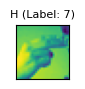

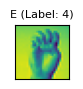

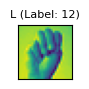

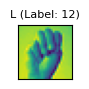

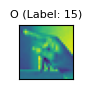

Expected (Input):   HELLO
True Labels:        HEMMP
Predicted Labels:   HEMMP
Accuracy:           100.00%
Showing translated images:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


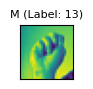

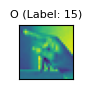

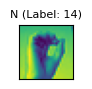

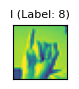

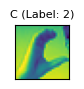

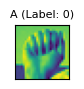

Expected (Input):   MONICA
True Labels:        NPOICA
Predicted Labels:   NPOICA
Accuracy:           100.00%
Showing translated images:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


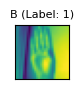

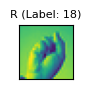

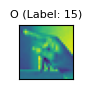

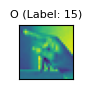

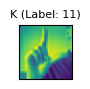

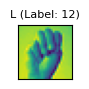

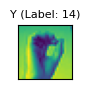

Expected (Input):   BROOKLYN
True Labels:        BSPPLMO
Predicted Labels:   BSPPLMO
Accuracy:           100.00%
Showing translated images:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


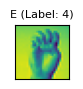

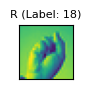

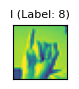

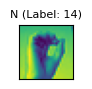

Expected (Input):   ERIN
True Labels:        ESIO
Predicted Labels:   ESIO
Accuracy:           100.00%
Showing translated images:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


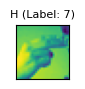

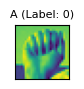

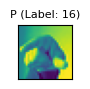

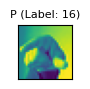

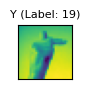

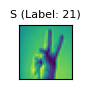

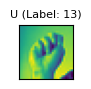

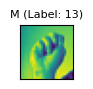

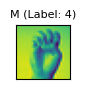

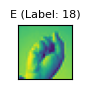

Expected (Input):   HAPPYSUMMER
True Labels:        HAQQTVNNES
Predicted Labels:   HAQQTVNNES
Accuracy:           100.00%


In [ ]:
# Translate and predict "HELLO"
full_sign_language_translation("HELLO")

# Translate and predict "MONICA"
full_sign_language_translation("MONICA")

# Translate and predict "BROOKLYN"
full_sign_language_translation("BROOKLYN")

# Translate and predict "ERIN"
full_sign_language_translation("ERIN")

# Translate and predict "HAPPY SUMMER"
full_sign_language_translation("HAPPYSUMMER")

This function succesfully transformed text into numerical data and visual signs. The values all match our training set, although some of the predictions were wrong.

In [ ]:
# Translate text to signs HELLO
translated_df = translate_text_to_signs("HELLO", "/content/hello_signs.csv")

#translate signs to text
true_text, pred_text, acc = translate_signs_to_text("/content/hello_signs.csv")



print("True:", true_text)
print("Predicted:", pred_text)
print(f"Accuracy: {acc:.2%}")


True: ['7', '4', '12', '12', '15']
Predicted: ['7', '4', '12', '12', '15']
Accuracy: 100.00%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Translate text to signs Monica
translated_df = translate_text_to_signs("MONICA", "/content/monica_signs.csv")

#Translate sign images back to predicted letters
true_text, pred_text, acc = translate_signs_to_text("/content/monica_signs.csv")

# Step 3: Print results
print("True:", true_text)
print("Predicted:", pred_text)
print(f"Accuracy: {acc:.2%}")


True: ['13', '15', '14', '8', '2', '0']
Predicted: ['13', '15', '14', '8', '2', '0']
Accuracy: 100.00%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Translate text to signs Brooklyn
translated_df = translate_text_to_signs("BROOKLYN", "/content/brooklyn_signs.csv")

#Translate sign images back to predicted letters
true_text, pred_text, acc = translate_signs_to_text("/content/brooklyn_signs.csv")

# Step 3: Print results
print("True:", true_text)
print("Predicted:", pred_text)
print(f"Accuracy: {acc:.2%}")


True: ['1', '18', '15', '15', '11', '12', '14']
Predicted: ['1', '18', '15', '15', '11', '12', '14']
Accuracy: 100.00%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Translate text to signs Erin
translated_df = translate_text_to_signs("ERIN", "/content/erin_signs.csv")

#Translate sign images back to predicted letters
true_text, pred_text, acc = translate_signs_to_text("/content/erin_signs.csv")

# Step 3: Print results
print("True:", true_text)
print("Predicted:", pred_text)
print(f"Accuracy: {acc:.2%}")


True: ['4', '18', '8', '14']
Predicted: ['4', '18', '8', '14']
Accuracy: 100.00%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Translate text to signs Happy Summer
translated_df = translate_text_to_signs("HAPPYSUMMER", "/content/happysummer_signs.csv")

#Translate sign images back to predicted letters
true_text, pred_text, acc = translate_signs_to_text("/content/happysummer_signs.csv")

# Step 3: Print results
print("True:", true_text)
print("Predicted:", pred_text)
print(f"Accuracy: {acc:.2%}")


True: ['7', '0', '16', '16', '19', '21', '13', '13', '4', '18']
Predicted: ['7', '0', '16', '16', '19', '21', '13', '13', '4', '18']
Accuracy: 100.00%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#indices=[3,29,20,4,15,1,0,9,10,6,62,13,180,7,27,54,80,68,33,50,22,16,135,117]
#rows_data = test_pdf.iloc[indices] #creating rows data based on test_pdf indices
#new_df = pd.DataFrame(rows_data) #creating new datafra,

#new_indices = ['A', 'B', 'C','D','E','F','G','H','I','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y'] #renaming rows to the letters that are
#new_df.index = new_indices #indexing the indices

***
# Write a summary of what you have learned in this exercise.

We learned a lot from this exercise. Image data (ASL) can be classified with the K-Nearest Neighbors model. Changing the K could impact performance. We could increase accuracy if we increased our num train value. The downside was that the run time increases. Accuracy may improve, but we might overfit the model.
We learned how to build a tool from a model by creating functions to translate sign to text and text to sign.